<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
# Desafio 4, LSTM Bot QA

In [1]:
import sys

# Instala librerías que podrían faltar al ejecutar en Colab

if 'google.colab' in sys.modules:
    print("Entorno Colab detectado. Asegurando instalación de librerias...")
    !pip install -q torchinfo

In [ ]:
# Descarga la libreria torch_helpers.py provista en el curso

url = "https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/scripts/torch_helpers.py"
filename = "torch_helpers.py"

if not os.path.exists(filename):
    print(f"Archivo '{filename}' no encontrado. Descargando...")
    try:
        response = requests.get(url)
        response.raise_for_status()  # Verifica si la descarga fue exitosa
        with open(filename, "wb") as f:
            f.write(response.content)
        print("Descarga completada con éxito.")
    except Exception as e:
        print(f"Error al descargar: {e}")
else:
    print(f"El archivo '{filename}' ya existe en el directorio.")

In [2]:
# Librerias requeridas

import os
import re
import json
import requests

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchinfo import summary

import urllib.request
import gzip
import shutil
import logging
from pathlib import Path
import pickle

from torch_helpers import Tokenizer

import time
import random
import math


import matplotlib.pyplot as plt

In [3]:
# Configurar el dispositivo para PyTorch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"El dispositivo seleccionado es: {device}")

if device.type == 'cuda':
    print(f"Nombre de la GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Se está utilizando la CPU.")

total_cores = os.cpu_count()
optimal_workers = 0 # Windows: 0 | Linux: min(total_cores - 2, 8)

print(f"Hardware detectado: {total_cores} núcleos.")
print(f"Asignando {optimal_workers} workers para optimizar la transferencia a la GPU.")

El dispositivo seleccionado es: cuda
Nombre de la GPU: NVIDIA GeForce RTX 5070 Ti
Hardware detectado: 24 núcleos.
Asignando 0 workers para optimizar la transferencia a la GPU.


### 1 - Datos
El objetivo es utilizar datos disponibles del challenge ConvAI2 (Conversational Intelligence Challenge 2) de conversaciones en inglés. Se construirá un BOT para responder a preguntas del usuario (QA).\
[LINK](http://convai.io/data/)

In [5]:
# Descarga el contenido del dataset desde github

url = "https://raw.githubusercontent.com/mgonzalez738/desafios_procesamiento_lenguaje_natural/main/data_volunteers.json"
filename = "data_volunteers.json"

if not os.path.exists(filename):
    print(f"Archivo '{filename}' no encontrado. Descargando...")
    try:
        response = requests.get(url)
        response.raise_for_status()  # Verifica si la descarga fue exitosa
        with open(filename, "wb") as f:
            f.write(response.content)
        print("Descarga completada con éxito.")
    except Exception as e:
        print(f"Error al descargar: {e}")
else:
    print(f"El archivo '{filename}' ya existe en el directorio.")

El archivo 'data_volunteers.json' ya existe en el directorio.


In [6]:
# Carga el archivo del dataset

if os.path.exists(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        data = json.load(f)
    print(f"Archivo cargado exitosamente. Total de conjuntos de dialogos: {len(data)}")
else:
    print("Error: No se encontró el archivo data_volunteers.json en la ruta especificada.")

# Imprime el primer objeto del dataset de forma legible

if len(data) > 0:
    print(json.dumps(data[8], indent=4))
else:
    print("El dataset está vacío.")

Archivo cargado exitosamente. Total de conjuntos de dialogos: 1111
{
    "dialog": [
        {
            "id": 0,
            "sender": "participant1",
            "text": "Hi!",
            "evaluation_score": null,
            "sender_class": "Human"
        },
        {
            "id": 1,
            "sender": "participant2",
            "text": "hi how are you today? i am doing well. ",
            "evaluation_score": null,
            "sender_class": "Bot"
        },
        {
            "id": 2,
            "sender": "participant1",
            "text": "Spent a day in my studio.",
            "evaluation_score": null,
            "sender_class": "Human"
        },
        {
            "id": 3,
            "sender": "participant2",
            "text": "that sounds fun. what kind of studio? ",
            "evaluation_score": null,
            "sender_class": "Bot"
        },
        {
            "id": 4,
            "sender": "participant1",
            "text": "Recording st

In [7]:
# Obtiene los pares de mensajes Human -> Bot y los preprocesa

# Función de limpieza de texto
# 1 - Convertir a minúsculas
# 2 - Expandir contracciones comunes (ej. "don't" -> "do not")
# 3 - Eliminar caracteres no alfanuméricos (excepto espacios)
def clean_text(txt):
    txt = txt.lower()
    txt = txt.replace("'d", " had")
    txt = txt.replace("'s", " is")
    txt = txt.replace("'m", " am")
    txt = txt.replace("don't", " do not")
    txt = txt.replace("can't", " cannot")
    txt = txt.replace("n't", " not")
    txt = re.sub(r"([?.!,])", r" \1 ", txt)    # Agrega espacios alrededor de signos de puntuación comunes
    txt = re.sub(r'[^a-z0-9?.!,\s]', ' ', txt) # Permite signos de puntuación comunes
    return " ".join(txt.split())

# Inicializa las listas para almacenar los pares de mensajes
input_sentences = []
output_sentences = []
output_sentences_inputs = []
max_words = 30

discarded_empty_message = 0
discarded_short_dialogs = 0
discarded_consecutive_turns = 0
discarded_by_length = 0

# Recorre cada diálogo en el dataset

for line in data:
    dialog = line.get('dialog', [])
    
    # Si el diálogo tiene menos de 2 mensajes lo ignora
    if len(dialog) < 2:
        discarded_short_dialogs += 1
        continue

    # Recorre el diálogo buscando pares Human -> Bot
    for i in range(len(dialog) - 1):
        msg_current = dialog[i]
        msg_next = dialog[i+1]
        
        # Validación solo pares Human -> Bot
        if msg_current.get('sender_class') == 'Human' and msg_next.get('sender_class') == 'Bot':
            
            raw_in = msg_current['text']
            raw_out = msg_next['text']
            
            chat_in = clean_text(raw_in)
            chat_out = clean_text(raw_out)
            
            if not chat_in or not chat_out:
                discarded_empty_message += 1
                continue
                
            if len(chat_in.split()) > max_words or len(chat_out.split()) > max_words:
                discarded_by_length += 1
                continue
                
            # Guarda el par de mensajes preprocesados
            input_sentences.append(chat_in)
            output_sentences_inputs.append(f'<sos> {chat_out}')
            output_sentences.append(f'{chat_out} <eos>')

        # Si el humano manda dos mensajes seguidos, o el bot dos seguidos, se ignoran    
        elif msg_current.get('sender_class') == msg_next.get('sender_class'):
            discarded_consecutive_turns += 1

print(f"Pares útiles extraídos: {len(input_sentences)}")
print(f"Descartados por solo tener un mensaje: {discarded_short_dialogs}")
print(f"Descartados por tener emisor consecutivo: {discarded_consecutive_turns}")
print(f"Descartados por exceder {max_words} palabras: {discarded_by_length}")
print(f"Descartados por tener algun mensajes vacío: {discarded_empty_message}")

print("\n Ejemplo de pares procesados:")

for i in range(4):
    print(f"  [Encoder Input]  : {input_sentences[i]}")
    print(f"  [Decoder Input]  : {output_sentences_inputs[i]}")
    print(f"  [Decoder Target] : {output_sentences[i]}")

Pares útiles extraídos: 6248
Descartados por solo tener un mensaje: 220
Descartados por tener emisor consecutivo: 1197
Descartados por exceder 30 palabras: 105
Descartados por tener algun mensajes vacío: 45

 Ejemplo de pares procesados:
  [Encoder Input]  : hello !
  [Decoder Input]  : <sos> hi ! how are you ?
  [Decoder Target] : hi ! how are you ? <eos>
  [Encoder Input]  : not bad ! and you ?
  [Decoder Input]  : <sos> i am doing well . just got engaged to my high school sweetheart .
  [Decoder Target] : i am doing well . just got engaged to my high school sweetheart . <eos>
  [Encoder Input]  : wowowowow ! congratulations ! is she pretty ?
  [Decoder Input]  : <sos> she is pretty cute . she invited me to dinner tonight .
  [Decoder Target] : she is pretty cute . she invited me to dinner tonight . <eos>
  [Encoder Input]  : cool ! have a good time you both ! and what is your hobby ?
  [Decoder Input]  : <sos> i love music ! i love taylor swift .
  [Decoder Target] : i love music ! 

### 2 - Preprocesamiento
Realizar el preprocesamiento necesario para obtener:
- word2idx_inputs, max_input_len
- word2idx_outputs, max_out_len, num_words_output
- encoder_input_sequences, decoder_output_sequences, decoder_targets

In [8]:
# Limita el vocabulario a las MAX_VOCAB_SIZE palabras más frecuentes
MAX_VOCAB_SIZE = 10000

In [9]:
# Inicializa el tokenizador para las preguntas del usuario 
# Evita filtrar signos de puntuacion comunes para preservar el significado de las frases (, . ? !)
input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='"<>¿¡#$%&()*+-/:;=@[\\]^_`{|}~\t\n')

# Ajusta el tokenizador mediante una lista de textos.
# Cuenta las palabras y asigna un índice a cada una, ordenándolas por frecuencia (mas usadas a menos usadas).
# El ID 0 se reserva para el padding.
input_tokenizer.fit_on_texts(input_sentences)

# Convierte cada texto en una secuencia de enteros, donde cada entero representa el índice de una palabra en el vocabulario.
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)

# Imprime el vocabulario y la longitud de la sentencia de entrada más larga

word2idx_inputs = input_tokenizer.word_index
print("Palabras en el vocabulario de entrada:", len(word2idx_inputs))
items_word2idx_inputs = list(word2idx_inputs.items())
print(f"\nLas 5 palabras más frecuentes del vocabulario:")
for palabra, token_id in items_word2idx_inputs[:5]:
    print(f"Token ID: {token_id:4} | Palabra: '{palabra}'")

max_input_len = max(len(sen) for sen in input_integer_seq)
print("\nSentencia de entrada más larga:", max_input_len)
for i in range(min(2, len(input_sentences))):
    text = input_sentences[i]
    sequence = input_integer_seq[i]
    print(f"\nEjemplo {i+1}:")
    print(f"Texto Original : '{text}'")
    print(f"Secuencia IDs  : {sequence}")

Palabras en el vocabulario de entrada: 3123

Las 5 palabras más frecuentes del vocabulario:
Token ID:    1 | Palabra: 'i'
Token ID:    2 | Palabra: '?'
Token ID:    3 | Palabra: 'you'
Token ID:    4 | Palabra: '.'
Token ID:    5 | Palabra: 'do'

Sentencia de entrada más larga: 30

Ejemplo 1:
Texto Original : 'hello !'
Secuencia IDs  : [49, 17]

Ejemplo 2:
Texto Original : 'not bad ! and you ?'
Secuencia IDs  : [14, 217, 17, 15, 3, 2]


In [10]:
# Inicializa el tokenizador para las respuestas del bot

# Evita filtrar signos de puntuacion comunes para preservar el significado de las frases (, . ? !) y < > para <sos> y <eos>
output_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='"¿¡#$%&()*+-/:;=@[\\]^_`{|}~\t\n')

# Ajusta el tokenizador mediante una lista de textos agregando los tokens especiales (solo falta <sos>).
output_tokenizer.fit_on_texts(["<sos>"] + output_sentences)

output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)

word2idx_outputs = output_tokenizer.word_index
print("Palabras en el vocabulario de salida:", len(word2idx_outputs))
items_word2idx_outputs = list(word2idx_outputs.items())
print(f"\nLas 5 palabras más frecuentes del vocabulario de salida:")
for palabra, token_id in items_word2idx_outputs[:5]:
    print(f"Token ID: {token_id:4} | Palabra: '{palabra}'")

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE) # Se suma 1 por el primer <sos>
max_out_len = max(len(sen) for sen in output_integer_seq)
print("\nSentencia de salida más larga:", max_out_len)

for i in range(min(1, len(output_sentences))):
    text = output_sentences[i]
    sequence = output_integer_seq[i]
    print(f"\nEjemplo {i+1}:")
    print(f"Texto Original : '{text}'")
    print(f"Secuencia IDs  : {sequence}")

for i in range(min(1, len(output_sentences_inputs))):
    text = output_sentences_inputs[i]
    sequence = output_input_integer_seq[i]
    print(f"Texto Original : '{text}'")
    print(f"Secuencia IDs  : {sequence}")


Palabras en el vocabulario de salida: 1780

Las 5 palabras más frecuentes del vocabulario de salida:
Token ID:    1 | Palabra: '<eos>'
Token ID:    2 | Palabra: '.'
Token ID:    3 | Palabra: 'i'
Token ID:    4 | Palabra: '?'
Token ID:    5 | Palabra: 'you'

Sentencia de salida más larga: 31

Ejemplo 1:
Texto Original : 'hi ! how are you ? <eos>'
Secuencia IDs  : [43, 30, 17, 14, 5, 4, 1]
Texto Original : '<sos> hi ! how are you ?'
Secuencia IDs  : [1118, 43, 30, 17, 14, 5, 4]


In [11]:
# Se crea esta función de padding por incompatibilidad de la función en la libreria con numpy >= 2.0.

def pad_sequences(sequences, maxlen=None, padding='pre', value=0):

    num_samples = len(sequences)
    
    # Si no se especifica maxlen, toma la de la secuencia más larga
    if maxlen is None:
        maxlen = max(len(s) for s in sequences)

    # Crea la matriz rectangular llena del valor de padding (0 por defecto)
    x = np.full((num_samples, maxlen), value, dtype='int32')

    for idx, s in enumerate(sequences):
        if not len(s):
            continue
            
        # Truncamiento (si la frase es más larga que maxlen, corta el final)
        trunc = s[:maxlen]
        
        # Padding 
        if padding == 'post':
            x[idx, :len(trunc)] = trunc
        else: # 'pre' (por defecto)
            x[idx, -len(trunc):] = trunc
            
    return x

In [12]:
# Genera las matrices de secuencias de enteros con padding para encoder y decoder

pad_token = 0

print("Cantidad de rows del dataset:", len(input_integer_seq))

encoder_input_sequences = pad_sequences(input_integer_seq, maxlen=max_input_len, value=pad_token)
print("encoder_input_sequences shape:", encoder_input_sequences.shape)

decoder_input_sequences = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post', value=pad_token)
print("decoder_input_sequences shape:", decoder_input_sequences.shape)

decoder_output_sequences = pad_sequences(output_integer_seq, maxlen=max_out_len, padding='post', value=pad_token)
print("decoder_output_sequences shape:", decoder_output_sequences.shape)

print("\nEjemplos de secuencias con padding:")
samples_qty = 1

for i in range(samples_qty):
    print(f"  Encoder Input (pre-padded) :\n  {encoder_input_sequences[i]}")
    print(f"  Decoder Input (post-padded) :\n  {decoder_input_sequences[i]}")
    print(f"  Decoder Output (post-padded) :\n  {decoder_output_sequences[i]}")

Cantidad de rows del dataset: 6248
encoder_input_sequences shape: (6248, 30)
decoder_input_sequences shape: (6248, 31)
decoder_output_sequences shape: (6248, 31)

Ejemplos de secuencias con padding:
  Encoder Input (pre-padded) :
  [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0 49 17]
  Decoder Input (post-padded) :
  [1118   43   30   17   14    5    4    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0]
  Decoder Output (post-padded) :
  [43 30 17 14  5  4  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0]


In [13]:
# Define la clase Dataset personalizada para manejar los datos de entrenamiento

class Data(Dataset):
    def __init__(self, encoder_input, decoder_input, decoder_output):
        # Convierte los arrays de numpy a tensores. 
        self.encoder_inputs = torch.tensor(encoder_input, dtype=torch.long)
        self.decoder_inputs = torch.tensor(decoder_input, dtype=torch.long)
        
        # Guardamos los targets como índices enteros.
        self.decoder_outputs = torch.tensor(decoder_output, dtype=torch.long)

        self.len = self.encoder_inputs.shape[0]

    def __getitem__(self, index):
        # Retorna el pack necesario para un paso de entrenamiento Seq2Seq
        return self.encoder_inputs[index], self.decoder_inputs[index], self.decoder_outputs[index]

    def __len__(self):
        return self.len


# Instancia el dataset personalizado con las secuencias de entrada, de salida y la cantidad de clases
data_set = Data(encoder_input_sequences, decoder_input_sequences, decoder_output_sequences)

# Guarda las dimensiones para la arquitectura del modelo
encoder_seq_len = data_set.encoder_inputs.shape[1]
decoder_seq_len = data_set.decoder_inputs.shape[1]
output_dim = num_words_output

print(f"Longitud secuencia Encoder: {encoder_seq_len}")
print(f"Longitud secuencia Decoder: {decoder_seq_len}")
print(f"Dimensión de salida (Vocab): {output_dim}")

# Separacion de entrenamiento y validacion

torch.manual_seed(42) 
valid_set_size = int(len(data_set) * 0.2)
train_set_size = len(data_set) - valid_set_size

train_set = Subset(data_set, range(train_set_size))
valid_set = Subset(data_set, range(train_set_size, len(data_set)))

print("Tamaño del conjunto de entrenamiento:", len(train_set))
print("Tamaño del conjunto de validacion:", len(valid_set))

# Crea los dataloaders para entrenamiento y validación

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=optimal_workers, pin_memory=True)
valid_loader = DataLoader(valid_set, batch_size=128, shuffle=False, num_workers=optimal_workers, pin_memory=True)

Longitud secuencia Encoder: 30
Longitud secuencia Decoder: 31
Dimensión de salida (Vocab): 1781
Tamaño del conjunto de entrenamiento: 4999
Tamaño del conjunto de validacion: 1249


### 3 - Preparar los embeddings
Utilizar los embeddings de Glove o FastText para transformar los tokens de entrada en vectores

In [14]:
# Descarga y extrae FastText para cargar los embeddings preentrenados

gz_file = 'cc.en.300.vec.gz'
vec_file = 'cc.en.300.vec'
pkl_file = 'fasttext.pkl'

# URL oficial de los vectores en inglés de FastText (Facebook Research)
fasttext_url = 'https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.vec.gz'

# Solo descarga si no existe ni el .pkl ni el .vec
if not os.path.exists(pkl_file) and not os.path.exists(vec_file):
    if not os.path.exists(gz_file):
        print(f"Descargando FastText (1.2 GB) desde {fasttext_url}...")
        urllib.request.urlretrieve(fasttext_url, gz_file)
        print("Descarga completada.")
    
    print(f"Descomprimiendo {gz_file}...")
    with gzip.open(gz_file, 'rb') as f_in:
        with open(vec_file, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    print("Descompresión completada.")
else:
    print("Los archivos de FastText ya están presentes o procesados.")

Los archivos de FastText ya están presentes o procesados.


In [15]:
# Clases de gestion de embeddings preentrenados de FastText

class WordsEmbeddings(object):
    logger = logging.getLogger(__name__)

    def __init__(self):
        words_embedding_pkl = Path(self.PKL_PATH)

        # Si no existe el pickle, lo crea parseando el archivo de texto 
        if not words_embedding_pkl.is_file():
            words_embedding_txt = Path(self.WORD_TO_VEC_MODEL_TXT_PATH)
            assert words_embedding_txt.is_file(), f'El archivo {self.WORD_TO_VEC_MODEL_TXT_PATH} no existe.'
            embeddings = self.convert_model_to_pickle()
        else:
            embeddings = self.load_model_from_pickle()
            
        self.embeddings = embeddings
        index = np.arange(self.embeddings.shape[0])
        
        # Diccionarios para traducir de palabra a IDX del embedding
        self.word2idx = dict(zip(self.embeddings['word'], index))
        self.idx2word = dict(zip(index, self.embeddings['word']))

    def get_words_embeddings(self, words):
        words_idxs = self.words2idxs(words)
        return self.embeddings[words_idxs]['embedding']

    def words2idxs(self, words):
        return np.array([self.word2idx.get(word, -1) for word in words])

    def idxs2words(self, idxs):
        return np.array([self.idx2word.get(idx, '-1') for idx in idxs])

    def load_model_from_pickle(self):
        print(f"Cargando embeddings desde la caché rápida: {self.PKL_PATH}")
        max_bytes = 2**28 - 1 # 256MB chunks
        bytes_in = bytearray(0)
        input_size = os.path.getsize(self.PKL_PATH)
        with open(self.PKL_PATH, 'rb') as f_in:
            for _ in range(0, input_size, max_bytes):
                bytes_in += f_in.read(max_bytes)
        embeddings = pickle.loads(bytes_in)
        return embeddings

    def convert_model_to_pickle(self):
        print(f"Parseando el archivo de texto {self.WORD_TO_VEC_MODEL_TXT_PATH} por primera vez...")
        print("Esto consumirá bastante RAM y tardará un rato. Al finalizar se creará un .pkl para que la próxima vez sea instantáneo.")
        
        structure = [('word', np.dtype('U' + str(self.WORD_MAX_SIZE))),
                     ('embedding', np.float32, (self.N_FEATURES,))]
        structure = np.dtype(structure)
        
        with open(self.WORD_TO_VEC_MODEL_TXT_PATH, encoding="utf8") as words_embeddings_txt:
            embeddings_gen = (
                (line.split()[0], line.split()[1:]) for line in words_embeddings_txt
                if len(line.split()[1:]) == self.N_FEATURES
            )
            embeddings = np.fromiter(embeddings_gen, structure)
            
        # Agregamos el "null embedding" (vector de ceros) al final para palabras no encontradas
        null_embedding = np.array(
            [('null_embedding', np.zeros((self.N_FEATURES,), dtype=np.float32))],
            dtype=structure
        )
        embeddings = np.concatenate([embeddings, null_embedding])
        
        print(f"Guardando caché en {self.PKL_PATH}...")
        max_bytes = 2**28 - 1 
        bytes_out = pickle.dumps(embeddings, protocol=pickle.HIGHEST_PROTOCOL)
        with open(self.PKL_PATH, 'wb') as f_out:
            for idx in range(0, len(bytes_out), max_bytes):
                f_out.write(bytes_out[idx:idx+max_bytes])
        return embeddings

class FasttextEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = vec_file
    PKL_PATH = pkl_file
    N_FEATURES = 300 
    WORD_MAX_SIZE = 60

In [16]:
# Creación de la matriz de embeddings de entrada

print('\nIniciando carga de FastText a memoria RAM...')
model_embeddings = FasttextEmbeddings() 

print('Cruzando vocabulario del Tokenizer con FastText para armar la Embedding Matrix...')
embed_dim = model_embeddings.N_FEATURES
words_not_found = []

# Determinar el tamaño de la matriz (max vocabulario o vocabulario real + 1 por padding)
nb_words = min(MAX_VOCAB_SIZE, len(word2idx_inputs) + 1)
embedding_matrix_inputs = np.zeros((nb_words, embed_dim), dtype=np.float32)

for word, i in word2idx_inputs.items():
    if i >= nb_words:
        continue
        
    # Pide el vector. Si no existe, devuelve el array de ceros (null_embedding)
    embedding_vector = model_embeddings.get_words_embeddings([word])[0]
    
    if np.any(embedding_vector): 
        embedding_matrix_inputs[i] = embedding_vector
    else:
        words_not_found.append(word)

print(f"\nForma de la Matriz de Embeddings : {embedding_matrix_inputs.shape}")
print(f"Dimensiones por palabra          : {embed_dim} (FastText)")
print(f"Palabras no encontradas (OOV)    : {len(words_not_found)}")
print(f"Porcentaje OOV                   : {(len(words_not_found) / nb_words) * 100:.2f}%")


Iniciando carga de FastText a memoria RAM...
Cargando embeddings desde la caché rápida: fasttext.pkl


Cruzando vocabulario del Tokenizer con FastText para armar la Embedding Matrix...

Forma de la Matriz de Embeddings : (3124, 300)
Dimensiones por palabra          : 300 (FastText)
Palabras no encontradas (OOV)    : 170
Porcentaje OOV                   : 5.44%


In [17]:
# Creación de la matriz de embeddings de salida

print('\nIniciando carga de FastText a memoria RAM...')
model_embeddings = FasttextEmbeddings() 

print('Cruzando vocabulario del Tokenizer con FastText para armar la Embedding Matrix...')
embed_dim = model_embeddings.N_FEATURES
words_not_found = []

# Determinar el tamaño de la matriz (max vocabulario o vocabulario real + 1 por padding)
nb_words = min(MAX_VOCAB_SIZE, len(word2idx_outputs) + 1)
embedding_matrix_outputs = np.zeros((nb_words, embed_dim), dtype=np.float32)

for word, i in word2idx_outputs.items():
    if i >= nb_words:
        continue
        
    # Pide el vector. Si no existe, devuelve el array de ceros (null_embedding)
    embedding_vector = model_embeddings.get_words_embeddings([word])[0]
    
    if np.any(embedding_vector): 
        embedding_matrix_outputs[i] = embedding_vector
    else:
        words_not_found.append(word)

print(f"\nForma de la Matriz de Embeddings : {embedding_matrix_outputs.shape}")
print(f"Dimensiones por palabra          : {embed_dim} (FastText)")
print(f"Palabras no encontradas (OOV)    : {len(words_not_found)}")
print(f"Porcentaje OOV                   : {(len(words_not_found) / nb_words) * 100:.2f}%")


Iniciando carga de FastText a memoria RAM...
Cargando embeddings desde la caché rápida: fasttext.pkl
Cruzando vocabulario del Tokenizer con FastText para armar la Embedding Matrix...

Forma de la Matriz de Embeddings : (1781, 300)
Dimensiones por palabra          : 300 (FastText)
Palabras no encontradas (OOV)    : 7
Porcentaje OOV                   : 0.39%


### 4 - Entrenar el modelo
Entrenar un modelo basado en el esquema encoder-decoder utilizando los datos generados en los puntos anteriores. Utilce como referencias los ejemplos vistos en clase.

In [18]:
# Construye el modelo (Encoder - Decoder - Seq2Seq)

class Encoder(nn.Module):
    def __init__(self, embedding_matrix, lstm_size, num_layers=1, dropout=0.5):
        super().__init__()
        self.lstm_size = lstm_size
        self.num_layers = num_layers
        
        # Extrae las dimensiones directamente de la matriz de embeddings
        _, embed_dim = embedding_matrix.shape

        # Crea la capa de embeddings inyectando los pesos de FastText
        self.embedding = nn.Embedding.from_pretrained(torch.FloatTensor(embedding_matrix), freeze=False) 

        # Capas LSTM
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=self.lstm_size, batch_first=True, num_layers=self.num_layers, dropout=dropout if num_layers > 1 else 0)

        # Dropout manual para aplicar sobre la salida del embedding
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x)) 
        _, (ht, ct) = self.lstm(embedded)
        return ht, ct

class Decoder(nn.Module):
    def __init__(self, embedding_matrix, lstm_size, num_layers=1, dropout=0.5):
        super().__init__()
        self.lstm_size = lstm_size
        self.num_layers = num_layers
        
        # Extrae las dimensiones directamente de la matriz de embeddings
        vocab_size, embed_dim = embedding_matrix.shape
        self.output_dim = vocab_size 

        # Crea la capa de embeddings inyectando los pesos de FastText
        self.embedding = nn.Embedding.from_pretrained(torch.FloatTensor(embedding_matrix), freeze=False) 

        # Capas LSTM
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=self.lstm_size, batch_first=True, num_layers=self.num_layers, dropout=dropout if num_layers > 1 else 0)
        
        # capa densa
        self.fc1 = nn.Linear(in_features=self.lstm_size, out_features=self.output_dim)

        # Dropout manual para aplicar sobre la salida del embedding
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, prev_state):
        embedded = self.dropout(self.embedding(x))
        lstm_output, (ht, ct) = self.lstm(embedded, prev_state)
        out = self.fc1(lstm_output.squeeze(1)) 
        return out, (ht, ct)

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device # Guarda el dispositivo para crear tensores ahí
        
        assert encoder.lstm_size == decoder.lstm_size, "Los hidden states deben ser iguales"
        assert encoder.num_layers == decoder.num_layers, "Deben tener las mismas capas"
        
    def forward(self, encoder_input, decoder_input, teacher_forcing_ratio=0.5):
        batch_size = decoder_input.shape[0]
        decoder_input_len = decoder_input.shape[1]
        vocab_size = self.decoder.output_dim
        
        # Tensor para almacenar la salida (creada en el device seleccionado)
        outputs = torch.zeros(batch_size, decoder_input_len, vocab_size).to(self.device)
        
        # Contexto del encoder
        prev_state = self.encoder(encoder_input)
      
        # En la primera iteracion se toma el primer token de target (<sos>)
        input_token = decoder_input[:, 0:1]

        for t in range(decoder_input_len):
            
            # Pasar por el decoder
            output, prev_state = self.decoder(input_token, prev_state)
            
            # Guardar predicción (logits)
            outputs[:, t, :] = output
            
            # Lógica dinámica de Teacher Forcing
            teacher_force = random.random() < teacher_forcing_ratio
            
            # Obtener el token predicho (el de mayor probabilidad)
            top1 = output.argmax(1).unsqueeze(1) # shape: (batch_size, 1)
            
            # Si no esta en el último paso, define cuál será la próxima entrada
            if t + 1 < decoder_input_len:
                if teacher_force:
                    input_token = decoder_input[:, t+1:t+2] # Usar el dato real
                else:
                    input_token = top1 # Usar la predicción del modelo

        return outputs

# Instancia el modelo seq2seq

lstm_size = 256
lstm_layers = 1

encoder_seq2seq = Encoder(embedding_matrix=embedding_matrix_inputs, lstm_size=lstm_size, num_layers=lstm_layers, dropout=0)
decoder_seq2seq = Decoder(embedding_matrix=embedding_matrix_outputs, lstm_size=lstm_size, num_layers=lstm_layers, dropout=0)
model_seq2seq = Seq2Seq(encoder_seq2seq, decoder_seq2seq, device).to(device)

# Optimizador (Adam)

optimizer_seq2seq = torch.optim.Adam(model_seq2seq.parameters(), lr=0.01)

# Función de pérdida (CrossEntropyLoss - Se ignora el pad token)

criterion_seq2seq = torch.nn.CrossEntropyLoss(ignore_index=pad_token)

# Extrae una muestra del Dataloader para tracear el modelo con summary (Forward Pass)

sample_encoder_input_seq2seq, sample_decoder_input_seq2seq, _ = next(iter(train_loader))

# Envia los tensores a la gpu

sample_encoder_input_seq2seq = sample_encoder_input_seq2seq.to(device)
sample_decoder_input_seq2seq = sample_decoder_input_seq2seq.to(device)

# Ejecuta el summary con los datos ya en la GPU

summary(model_seq2seq, input_data=(sample_encoder_input_seq2seq, sample_decoder_input_seq2seq))

Layer (type:depth-idx)                   Output Shape              Param #
Seq2Seq                                  [128, 31, 1781]           --
├─Encoder: 1-1                           [1, 128, 256]             --
│    └─Embedding: 2-1                    [128, 30, 300]            937,200
│    └─Dropout: 2-2                      [128, 30, 300]            --
│    └─LSTM: 2-3                         [128, 30, 256]            571,392
├─Decoder: 1-2                           [128, 1781]               --
│    └─Embedding: 2-4                    [128, 1, 300]             534,300
│    └─Dropout: 2-5                      [128, 1, 300]             --
│    └─LSTM: 2-6                         [128, 1, 256]             571,392
│    └─Linear: 2-7                       [128, 1781]               457,717
├─Decoder: 1-3                           [128, 1781]               (recursive)
│    └─Embedding: 2-8                    [128, 1, 300]             (recursive)
│    └─Dropout: 2-9                      [

In [19]:
# Funciones para el entrenamiento

# Calcula el accuracy vectorizado, ignorando los tokens de padding

def sequence_acc(y_pred, y_test, pad_token_id=0):

    # Obtiene la clase con mayor probabilidad
    preds = y_pred.argmax(dim=-1) # shape: (batch_size, seq_len)
    
    # Crea una máscara para ignorar los ceros (padding)
    mask = (y_test != pad_token_id)
    
    # Compara predicciones con target, solo donde la máscara es True
    correct = (preds == y_test) & mask
    
    # Calcula el promedio dividiendo por la cantidad de tokens reales (no ceros)
    acc = correct.sum().float() / mask.sum().float()
    return acc.item()

# Funcion de entrenamiento

def train(model, train_loader, valid_loader, optimizer, criterion, device, epochs=100, pad_token_id=0):
    train_loss, train_accuracy = [], []
    valid_loss, valid_accuracy = [], []

    # Aplica Schedule Sampling (El ratio de Teacher Forcing decae a medida que avanza el entrenmiento)
    start_tf_ratio = 1.0 # Arranca con 100% de ayuda
    end_tf_ratio = 0.0   # Termina con solo 0% de ayuda

    for epoch in range(epochs):

        start_time = time.time()
        
        # Calcula el ratio de Teacher Forcing para esta época (decaimiento lineal)
        if epochs > 1:
            current_tf_ratio = start_tf_ratio - ((start_tf_ratio - end_tf_ratio) * (epoch / (epochs - 1)))
        else:
            current_tf_ratio = start_tf_ratio
            
        # Entrenamiento

        model.train() 
        epoch_train_loss = 0.0
        epoch_train_accuracy = 0.0

        for enc_in, dec_in, target in train_loader:
            enc_in = enc_in.to(device)
            dec_in = dec_in.to(device)
            target = target.to(device)

            optimizer.zero_grad()

            # Teacher forcing ratio decae linealmente en entrenamiento
            output = model(enc_in, dec_in, teacher_forcing_ratio=current_tf_ratio)

            output_reshaped = output.view(-1, output.shape[-1])
            target_reshaped = target.view(-1)

            loss = criterion(output_reshaped, target_reshaped)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_train_loss += loss.item()
            epoch_train_accuracy += sequence_acc(output, target, pad_token_id)

        avg_train_loss = epoch_train_loss / len(train_loader)
        avg_train_acc = epoch_train_accuracy / len(train_loader)
        train_loss.append(avg_train_loss)
        train_accuracy.append(avg_train_acc)

        # Validación

        model.eval() 
        epoch_valid_loss = 0.0
        epoch_valid_accuracy = 0.0

        with torch.no_grad(): 
            for enc_in, dec_in, target in valid_loader:
                enc_in = enc_in.to(device)
                dec_in = dec_in.to(device)
                target = target.to(device)

                # Teacher forcing ratio siempre cero en validación
                output = model(enc_in, dec_in, teacher_forcing_ratio=0.0)

                output_reshaped = output.view(-1, output.shape[-1])
                target_reshaped = target.view(-1)

                loss = criterion(output_reshaped, target_reshaped)
                
                epoch_valid_loss += loss.item()
                epoch_valid_accuracy += sequence_acc(output, target, pad_token_id)

        avg_valid_loss = epoch_valid_loss / len(valid_loader)
        avg_valid_acc = epoch_valid_accuracy / len(valid_loader)
        valid_loss.append(avg_valid_loss)
        valid_accuracy.append(avg_valid_acc)
        
        end_time = time.time()
        duracion_total = end_time - start_time

        print(f"Epoch: {epoch+1:02}/{epochs} | Tiempo: {duracion_total:.2f}s")
        print(f"\tTrain Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc*100:.2f}%")
        print(f"\tValid Loss: {avg_valid_loss:.4f} | Valid Acc: {avg_valid_acc*100:.2f}%")

    history = {
        "loss": train_loss, "accuracy": train_accuracy,
        "val_loss": valid_loss, "val_accuracy": valid_accuracy,
    }
    return history

Iniciando el entrenamiento en el dispositivo: cuda...
Epoch: 01/40 | Tiempo: 1.73s
	Train Loss: 3.5148 | Train Acc: 35.74%
	Valid Loss: 6.1020 | Valid Acc: 9.56%
Epoch: 02/40 | Tiempo: 1.47s
	Train Loss: 2.2195 | Train Acc: 52.50%
	Valid Loss: 6.9611 | Valid Acc: 12.41%
Epoch: 03/40 | Tiempo: 1.52s
	Train Loss: 1.9508 | Train Acc: 55.23%
	Valid Loss: 6.8741 | Valid Acc: 12.94%
Epoch: 04/40 | Tiempo: 1.54s
	Train Loss: 1.8557 | Train Acc: 56.60%
	Valid Loss: 6.6914 | Valid Acc: 12.71%
Epoch: 05/40 | Tiempo: 1.69s
	Train Loss: 1.7731 | Train Acc: 58.02%
	Valid Loss: 6.8655 | Valid Acc: 13.51%
Epoch: 06/40 | Tiempo: 1.72s
	Train Loss: 1.6840 | Train Acc: 59.44%
	Valid Loss: 6.6905 | Valid Acc: 12.96%
Epoch: 07/40 | Tiempo: 1.69s
	Train Loss: 1.6595 | Train Acc: 59.76%
	Valid Loss: 6.6732 | Valid Acc: 12.05%
Epoch: 08/40 | Tiempo: 1.62s
	Train Loss: 1.6528 | Train Acc: 60.36%
	Valid Loss: 7.0218 | Valid Acc: 12.75%
Epoch: 09/40 | Tiempo: 1.66s
	Train Loss: 1.6274 | Train Acc: 61.07%
	Valid

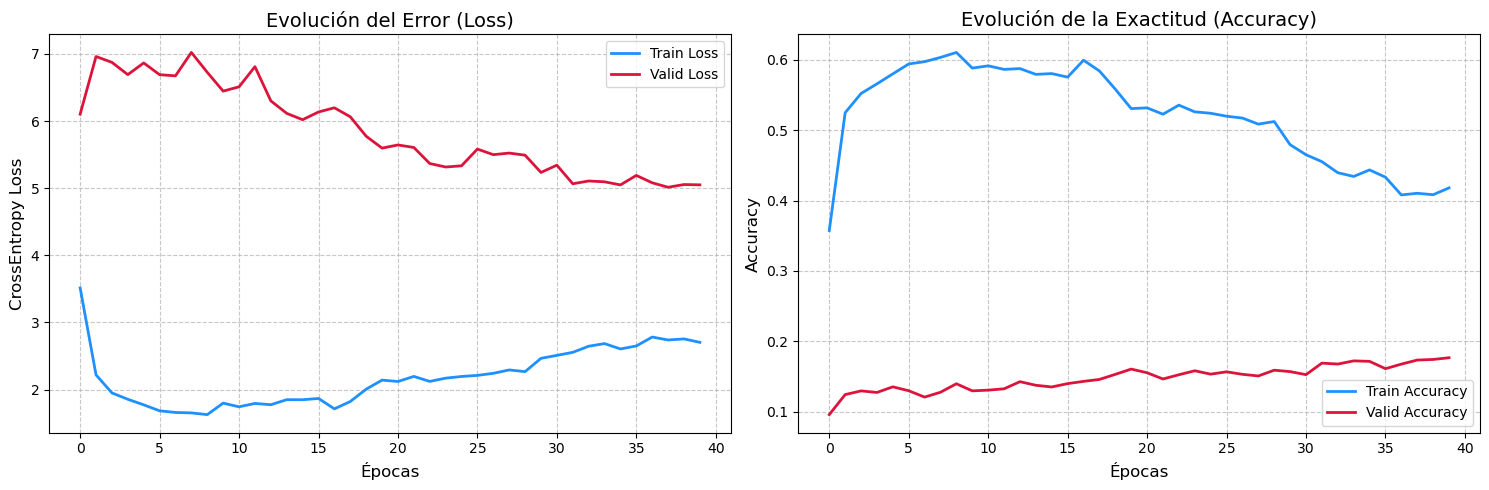

In [20]:
# Entrena el modelo Seq2Seq

EPOCHS = 40

print(f"Iniciando el entrenamiento en el dispositivo: {device}...")

historial = train(
    model=model_seq2seq, 
    train_loader=train_loader, 
    valid_loader=valid_loader, 
    optimizer=optimizer_seq2seq, 
    criterion=criterion_seq2seq, 
    device=device,
    epochs=EPOCHS, 
    pad_token_id=pad_token
)

print("Entrenamiento finalizado.")

# Grafica la evolución de la pérdida y la precisión

def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Gráfico de Pérdida (Loss) 
    ax1.plot(history['loss'], label='Train Loss', color='dodgerblue', linewidth=2)
    ax1.plot(history['val_loss'], label='Valid Loss', color='crimson', linewidth=2)
    ax1.set_title('Evolución del Error (Loss)', fontsize=14)
    ax1.set_xlabel('Épocas', fontsize=12)
    ax1.set_ylabel('CrossEntropy Loss', fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Gráfico de Exactitud (Accuracy)
    ax2.plot(history['accuracy'], label='Train Accuracy', color='dodgerblue', linewidth=2)
    ax2.plot(history['val_accuracy'], label='Valid Accuracy', color='crimson', linewidth=2)
    ax2.set_title('Evolución de la Exactitud (Accuracy)', fontsize=14)
    ax2.set_xlabel('Épocas', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.legend(loc='lower right')
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_history(historial)

En las gráficas de train se observa el efecto del Schedule Sampling.   
A medida que el ratio de Teacher Forcing decae, en train el loss aumenta y el accuracy disminuyen mientras que en val ambos continuan mejorando.

### 5 - Inferencia
Experimentar el funcionamiento de su modelo. Recuerde que debe realizar la inferencia de los modelos por separado de encoder y decoder.

In [21]:
def chatbot_seq2seq(input_text, model, device, max_len=30):
    
    sos_token_id = word2idx_outputs['<sos>']
    eos_token_id = word2idx_outputs['<eos>']
   
    model.eval() # Congela el modelo
    
    # Preprocesa y la entrada
    cleaned_text = clean_text(input_text)
    
    # Tokeniza
    seq = input_tokenizer.texts_to_sequences([cleaned_text])
    
    # Aplica pre padding
    padded_seq = pad_sequences(seq, maxlen=max_input_len, padding='pre', value=pad_token)
    
    # Tensoriza
    encoder_input = torch.tensor(padded_seq, dtype=torch.long).to(device)
    
    with torch.no_grad():

        # Pasa por el Encoder para obtener el contexto
        prev_state = model.encoder(encoder_input)
        
        # Prepara el primer token del Decoder (<sos>)
        decoder_input = torch.tensor([[sos_token_id]], dtype=torch.long).to(device)
        
        output_tokens = []
        
        # Bucle generativo palabra por palabra

        for _ in range(max_len):

            # Pasa un token por vez
            output, prev_state = model.decoder(decoder_input, prev_state)
            
            # Obtiene la palabra con mayor probabilidad (Greedy Decoding)
            top1_id = output.argmax(1).item()
            
            # Condición de corte: Si predice <eos> o padding corta
            if top1_id == eos_token_id or top1_id == pad_token:
                break

            # Condición de corte: Si repite . corta
            if len(output_tokens) > 0 and top1_id == output_tokens[-1]:
                palabra_repetida = {v: k for k, v in word2idx_outputs.items()}.get(top1_id, '')
                if palabra_repetida == '.':
                    break
                
            output_tokens.append(top1_id)
            
            # La predicción actual es la entrada del siguiente ciclo
            decoder_input = torch.tensor([[top1_id]], dtype=torch.long).to(device)
            
    # Decodificar los IDs de vuelta a palabras
    idx2word_outputs = {v: k for k, v in word2idx_outputs.items()}
    output_sentence = ' '.join([idx2word_outputs.get(idx, '<UNK>') for idx in output_tokens])
    
    return output_sentence

# Frases de prueba

frases_prueba = [
    "hello !",
    "Hi",
    "How old are you?",
    "how are you today?",
    "what is your hobby?",
    "do you like music?",
    "do you read?",
    "Do you have any pet?",
    "Where are you from?"
]

for frase in frases_prueba:
    respuesta = chatbot_seq2seq(frase, model_seq2seq, device)
    print(f"👤 User: {frase}")
    print(f"🤖 Bot:  {respuesta}\n")

👤 User: hello !
🤖 Bot:  hello , how are you ?

👤 User: Hi
🤖 Bot:  hello , how are you ?

👤 User: How old are you?
🤖 Bot:  i am doing well . how are you ?

👤 User: how are you today?
🤖 Bot:  i am doing well . how are you ?

👤 User: what is your hobby?
🤖 Bot:  i love to walk .

👤 User: do you like music?
🤖 Bot:  i do . i .

👤 User: do you read?
🤖 Bot:  i like to play video games .

👤 User: Do you have any pet?
🤖 Bot:  i do not like .

👤 User: Where are you from?
🤖 Bot:  i am from cali .



Genera algunas frases coherentes. Se confunde un poco.

### 6 - Evaluacion de un Transformer

Se toma como modelo el ejemplo desarrollado en https://www.datacamp.com/tutorial/building-a-transformer-with-py-torch

In [22]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        # Valida que la dimensión del modelo (d_model) sea divisible por el número de cabezales
        assert d_model % num_heads == 0, "d_model debe ser divisible por num_heads"
        
        # Inicialización de dimensiones
        self.d_model = d_model          # Dimensión total del modelo
        self.num_heads = num_heads      # Cantidad de cabezales de atención
        self.d_k = d_model // num_heads # Dimensión de cada cabezal (Query, Key y Value)
        
        # Capas lineales para transformar las entradas
        self.W_q = nn.Linear(d_model, d_model) # Transformación para las Consultas (Queries)
        self.W_k = nn.Linear(d_model, d_model) # Transformación para las Claves (Keys)
        self.W_v = nn.Linear(d_model, d_model) # Transformación para los Valores (Values)
        self.W_o = nn.Linear(d_model, d_model) # Transformación para la salida final
        
    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        # Calcula los puntajes de atención (similitud entre Q y K)
        # Se divide por la raíz cuadrada de d_k para estabilizar los gradientes
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        # Aplica máscara si se proporciona (útil para ignorar el padding)
        if mask is not None:
            # Reemplaza los valores donde la máscara es 0 con un número muy pequeño (-infinito)
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        
        # Aplica Softmax para obtener las probabilidades de atención (suman 1)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        
        # Pondera los Valores (V) por las probabilidades obtenidas
        output = torch.matmul(attn_probs, V)
        return output
        
    def split_heads(self, x):
        # Reorganiza la entrada para dividir la dimensión d_model en num_heads
        batch_size, seq_length, d_model = x.size()
        # Cambia la forma a (batch, seq_len, heads, d_k) y transpone a (batch, heads, seq_len, d_k)
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)
        
    def combine_heads(self, x):
        # Recombina los múltiples cabezales a la forma original (batch, seq_len, d_model)
        batch_size, _, seq_length, d_k = x.size()
        # Transpone y vuelve a unir las dimensiones de los cabezales
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)
        
    def forward(self, Q, K, V, mask=None):
        # Aplica transformaciones lineales y divide en múltiples cabezales
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))
        
        # Realiza la atención de producto punto escalado (Scaled Dot-Product Attention)
        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        
        # Combina los cabezales y aplica la transformación lineal de salida final
        output = self.W_o(self.combine_heads(attn_output))
        return output
    
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()

        # Proyecta la dimensión del modelo a una escala mayor (d_ff)
        # d_ff suele ser 4 veces d_model (ej: 512 -> 2048)
        self.fc1 = nn.Linear(d_model, d_ff)

        # Función de activación no lineal
        self.relu = nn.ReLU()
        
        # Proyecta de vuelta a la dimensión original del modelo
        self.fc2 = nn.Linear(d_ff, d_model)
        
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))
    
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()
        
        # Crea una matriz de ceros que almacenará los "encodings" posicionales
        # Forma: (Longitud máxima de secuencia, Dimensión del modelo)
        pe = torch.zeros(max_seq_length, d_model)
        
        # Crea un vector con las posiciones (0, 1, 2, ..., max_seq_length-1)
        # unsqueeze(1) lo convierte de [max_len] a [max_len, 1] para poder operar
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        
        # Calcula el término de división (div_term) para las frecuencias
        # Esto genera una escala logarítmica para que cada dimensión del embedding tenga una longitud de onda diferente.
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        
        # Aplica la función SENO a las columnas pares (0, 2, 4...)
        pe[:, 0::2] = torch.sin(position * div_term)
        
        # Aplica la función COSENO a las columnas impares (1, 3, 5...)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # Registrar 'pe' como un buffer de la red. 
        # No es un parámetro (no se entrena), pero es parte del estado del modelo.
        # unsqueeze(0) añade la dimensión del batch: (1, max_len, d_model)
        self.register_buffer('pe', pe.unsqueeze(0))
        
    def forward(self, x):
        # Suma el encoding posicional a los embeddings de entrada (x)
        # Se recorta 'pe' para que coincida con la longitud real de la secuencia de x.
        return x + self.pe[:, :x.size(1)]
    
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()

        # Mecanismo de Auto-Atención (Self-Attention)
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        
        # Red de alimentación hacia adelante (Feed-Forward)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        
        # Capas de normalización (LayerNorm) para estabilizar cada subcapa
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        # Dropout para regularizar y evitar el sobreajuste (overfitting)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask):
        
        # Auto Atención
        # Calcula la atención (pasamos x como Query, Key y Value)
        attn_output = self.self_attn(x, x, x, mask)
        
        # Conexión residual + Dropout + Normalización
        # Se suma la entrada original 'x' a la salida procesada (Residual Connection)
        x = self.norm1(x + self.dropout(attn_output))
        
        # Feed-Forward
        # Procesa la información de la atención de forma independiente por posición
        ff_output = self.feed_forward(x)
        
        # Conexión residual + Dropout + Normalización
        x = self.norm2(x + self.dropout(ff_output))
        
        return x
    
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        # Mecanismo de Auto-Atención (Self-Attention)
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        
        # Mecanismo de Atención Cruzada (Cross-Attention)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        
        # 3. Red de alimentación hacia adelante (Feed-Forward)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        
        # Capas de normalización (LayerNorm) para estabilizar cada subcapa
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        
        # Dropout para regularizar y evitar el sobreajuste (overfitting)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, enc_output, src_mask, tgt_mask):
        
        # Auto Atencion
        # tgt_mask evita que preste atencion a palabras futuras.
        attn_output = self.self_attn(x, x, x, tgt_mask)

        # Conexión residual + Dropout + Normalización
        x = self.norm1(x + self.dropout(attn_output))
        
        # Atención Cruzada
        # Decoder usa su estado actual (x) como Query (Q) y busca información 
        # en la salida del Encoder (enc_output), que actúa como Key (K) y Value (V).
        attn_output = self.cross_attn(x, enc_output, enc_output, src_mask)

        # Conexión residual + Dropout + Normalización
        x = self.norm2(x + self.dropout(attn_output))
        
        # Feed-Forward
        ff_output = self.feed_forward(x)

        # Conexión residual + Dropout + Normalización
        x = self.norm3(x + self.dropout(ff_output))
        
        return x
    
class Transformer(nn.Module):
    def __init__(self, embedding_matrix_inputs, embedding_matrix_outputs, num_heads, num_layers, d_ff, max_seq_length, dropout):
        super(Transformer, self).__init__()

        # Extrae las dimensiones directamente de las matrices NumPy
        src_vocab_size, d_model_src = embedding_matrix_inputs.shape
        tgt_vocab_size, d_model_tgt = embedding_matrix_outputs.shape

        # Validación de seguridad: FastText tiene 300 en ambos, pero no está de más
        assert d_model_src == d_model_tgt, "Los embeddings de entrada y salida deben tener la misma dimensión"
        d_model = d_model_src # Esto será 300

        # Capas de Embedding: Convierten índices de palabras en vectores densos
        self.encoder_embedding = nn.Embedding.from_pretrained(torch.FloatTensor(embedding_matrix_inputs), freeze=False)
        self.decoder_embedding = nn.Embedding.from_pretrained(torch.FloatTensor(embedding_matrix_outputs), freeze=False)
        
        # Inyección de información posicional
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)

        # Pilas de capas (ModuleList) 
        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        # Capa lineal final: Proyecta la salida a la dimensión del vocabulario de destino
        self.fc = nn.Linear(d_model, tgt_vocab_size)
        
        self.dropout = nn.Dropout(dropout)

    def generate_mask(self, src, tgt):

        # Máscara para la fuente (src): ignora los tokens de relleno (padding != 0)
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2)
        
        # Máscara para el destino (tgt): ignora padding
        tgt_mask = (tgt != 0).unsqueeze(1).unsqueeze(3)
        
        # Máscara de "no mirar hacia adelante" (Look-ahead mask)
        # Crea una matriz triangular para que la posición 'i' no vea la 'i+1'
        seq_length = tgt.size(1)
        device = src.device
        nopeak_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length, device=device), diagonal=1)).bool()
        
        # Combina ambas máscaras para el destino
        tgt_mask = tgt_mask & nopeak_mask
        return src_mask, tgt_mask

    def forward(self, src, tgt):

        # Generar las máscaras necesarias para esta pasada
        src_mask, tgt_mask = self.generate_mask(src, tgt)
        
        # Procesa Embeddings + Posición + Dropout para Fuente y Destino
        src_embedded = self.dropout(self.positional_encoding(self.encoder_embedding(src)))
        tgt_embedded = self.dropout(self.positional_encoding(self.decoder_embedding(tgt)))

        # Pasa la información por la pila del Encoder
        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            enc_output = enc_layer(enc_output, src_mask)

        # Pasa la información por la pila del Decoder
        # El Decoder recibe su propia entrada y la salida del Encoder (enc_output)
        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            dec_output = dec_layer(dec_output, enc_output, src_mask, tgt_mask)

        # Capa final para obtener las predicciones
        output = self.fc(dec_output)

        return output
    
# Instancia el modelo transformer

num_heads = 6        # Obligatorio para que 300 sea divisible
num_layers = 2       # 2 o 3 capas es un buen punto de partida
d_ff = 1024          # Suelen ser 3 o 4 veces el d_model (300 -> ~1024)
max_seq_len = 31     
dropout = 0.1       

model_transformer = Transformer(
    embedding_matrix_inputs=embedding_matrix_inputs,
    embedding_matrix_outputs=embedding_matrix_outputs,
    num_heads=num_heads,
    num_layers=num_layers,
    d_ff=d_ff,
    max_seq_length=max_seq_len,
    dropout=dropout
).to(device)

# Optimizador (Adam)

optimizer_transformer = torch.optim.Adam(model_transformer.parameters(), lr=0.001)

# Función de pérdida (CrossEntropyLoss - Se ignora el pad token)

criterion_transformer = torch.nn.CrossEntropyLoss(ignore_index=pad_token)

# Extrae una muestra del Dataloader para tracear el modelo (Forward Pass)

sample_encoder_input_transformer, sample_decoder_input_transformer, _ = next(iter(train_loader))

# Manda los tensores a la gpu

sample_encoder_input_transformer = sample_encoder_input_transformer.to(device)
sample_decoder_input_transformer = sample_decoder_input_transformer.to(device)

# Ejecut el summary con los datos ya en la GPU
summary(model_transformer, input_data=(sample_encoder_input_transformer, sample_decoder_input_transformer))

Layer (type:depth-idx)                        Output Shape              Param #
Transformer                                   [128, 31, 1781]           --
├─Embedding: 1-1                              [128, 30, 300]            937,200
├─PositionalEncoding: 1-2                     [128, 30, 300]            --
├─Dropout: 1-3                                [128, 30, 300]            --
├─Embedding: 1-4                              [128, 31, 300]            534,300
├─PositionalEncoding: 1-5                     [128, 31, 300]            --
├─Dropout: 1-6                                [128, 31, 300]            --
├─ModuleList: 1-7                             --                        --
│    └─EncoderLayer: 2-1                      [128, 30, 300]            --
│    │    └─MultiHeadAttention: 3-1           [128, 30, 300]            361,200
│    │    └─Dropout: 3-2                      [128, 30, 300]            --
│    │    └─LayerNorm: 3-3                    [128, 30, 300]            600
│   

In [23]:
# Funcion para el entrenamiento

def train_transformer(model, train_loader, valid_loader, optimizer, criterion, device, epochs=50, pad_token_id=0):
    train_loss, train_accuracy = [], []
    valid_loss, valid_accuracy = [], []

    for epoch in range(epochs):
        start_time = time.time()
        
        # Entrenamiento

        model.train() 
        epoch_train_loss = 0.0
        epoch_train_accuracy = 0.0

        for enc_in, dec_in, target in train_loader:
            enc_in = enc_in.to(device)
            dec_in = dec_in.to(device)
            target = target.to(device)

            optimizer.zero_grad()

            output = model(enc_in, dec_in)

            output_dim = output.shape[-1]
            output_reshaped = output.view(-1, output_dim)
            target_reshaped = target.view(-1)

            loss = criterion(output_reshaped, target_reshaped)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_train_loss += loss.item()
            epoch_train_accuracy += sequence_acc(output, target, pad_token_id)

        avg_train_loss = epoch_train_loss / len(train_loader)
        avg_train_acc = epoch_train_accuracy / len(train_loader)
        train_loss.append(avg_train_loss)
        train_accuracy.append(avg_train_acc)

        # Evaluación

        model.eval() 
        epoch_valid_loss = 0.0
        epoch_valid_accuracy = 0.0

        with torch.no_grad(): 
            for enc_in, dec_in, target in valid_loader:
                enc_in = enc_in.to(device)
                dec_in = dec_in.to(device)
                target = target.to(device)

                output = model(enc_in, dec_in)

                output_reshaped = output.view(-1, output.shape[-1])
                target_reshaped = target.view(-1)

                loss = criterion(output_reshaped, target_reshaped)
                
                epoch_valid_loss += loss.item()
                epoch_valid_accuracy += sequence_acc(output, target, pad_token_id)

        avg_valid_loss = epoch_valid_loss / len(valid_loader)
        avg_valid_acc = epoch_valid_accuracy / len(valid_loader)
        valid_loss.append(avg_valid_loss)
        valid_accuracy.append(avg_valid_acc)
        
        end_time = time.time()
        duracion_total = end_time - start_time

        print(f"Epoch: {epoch+1:02}/{epochs} | Tiempo: {duracion_total:.2f}s")
        print(f"\tTrain Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc*100:.2f}%")
        print(f"\tValid Loss: {avg_valid_loss:.4f} | Valid Acc: {avg_valid_acc*100:.2f}%")

    history = {
        "loss": train_loss, "accuracy": train_accuracy,
        "val_loss": valid_loss, "val_accuracy": valid_accuracy,
    }
    return history

Iniciando el entrenamiento en el dispositivo: cuda...
Epoch: 01/30 | Tiempo: 0.64s
	Train Loss: 4.1491 | Train Acc: 24.33%
	Valid Loss: 3.3709 | Valid Acc: 37.91%
Epoch: 02/30 | Tiempo: 0.65s
	Train Loss: 2.8375 | Train Acc: 43.70%
	Valid Loss: 2.9229 | Valid Acc: 43.19%
Epoch: 03/30 | Tiempo: 0.63s
	Train Loss: 2.3909 | Train Acc: 49.88%
	Valid Loss: 2.6281 | Valid Acc: 46.82%
Epoch: 04/30 | Tiempo: 0.66s
	Train Loss: 2.1648 | Train Acc: 52.23%
	Valid Loss: 2.4938 | Valid Acc: 49.89%
Epoch: 05/30 | Tiempo: 0.64s
	Train Loss: 2.0061 | Train Acc: 54.36%
	Valid Loss: 2.4284 | Valid Acc: 50.88%
Epoch: 06/30 | Tiempo: 0.64s
	Train Loss: 1.8776 | Train Acc: 55.73%
	Valid Loss: 2.4022 | Valid Acc: 51.81%
Epoch: 07/30 | Tiempo: 0.59s
	Train Loss: 1.7687 | Train Acc: 57.14%
	Valid Loss: 2.4129 | Valid Acc: 50.77%
Epoch: 08/30 | Tiempo: 0.59s
	Train Loss: 1.6923 | Train Acc: 58.08%
	Valid Loss: 2.3606 | Valid Acc: 52.88%
Epoch: 09/30 | Tiempo: 0.64s
	Train Loss: 1.6327 | Train Acc: 58.62%
	Vali

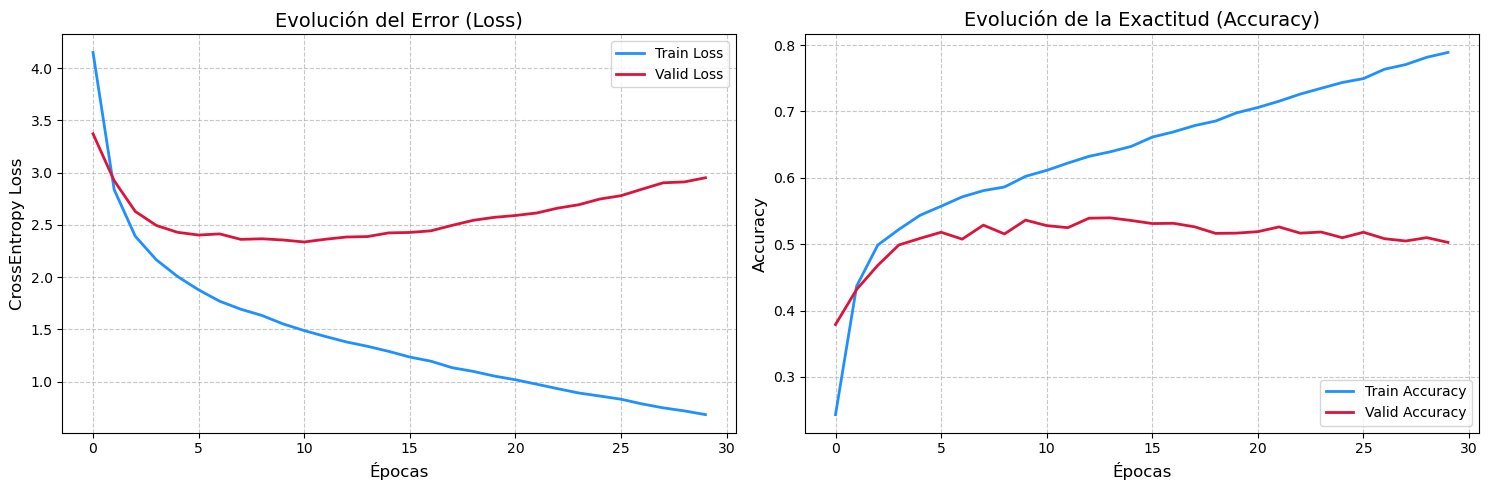

In [24]:
# Entrena el modelo transformer

EPOCHS = 30

print(f"Iniciando el entrenamiento en el dispositivo: {device}...")

historial_transformer = train_transformer(
    model=model_transformer, 
    train_loader=train_loader, 
    valid_loader=valid_loader, 
    optimizer=optimizer_transformer, 
    criterion=criterion_transformer, 
    device=device,
    epochs=EPOCHS, 
    pad_token_id=pad_token
)

print("Entrenamiento finalizado.")

# Grafica la evolución de la pérdida y la precisión

plot_history(historial_transformer)

Se ajustaron la épocas al  punto deonde se veía overfitting. Se observa una exactituda mayor a la del modelo anterior.

In [25]:
def chatbot_transformer(input_text, model, device, max_len=30):

    sos_token_id = word2idx_outputs['<sos>']
    eos_token_id = word2idx_outputs['<eos>']

    model.eval() # Congela el modelo
    
    # Preprocesa la entrada
    cleaned_text = clean_text(input_text)

    # Tokeniza
    seq = input_tokenizer.texts_to_sequences([cleaned_text])
    
    # Aplica pre padding
    padded_seq = pad_sequences(seq, maxlen=max_input_len, padding='pre', value=pad_token)

     # Tensoriza            
    encoder_input = torch.tensor(padded_seq, dtype=torch.long).to(device)
      
    with torch.no_grad():

        # Prepara el primer token del Decoder (<sos>)
        decoder_input = torch.tensor([[sos_token_id]], dtype=torch.long).to(device)
        
        output_tokens = []
        
        # Bucle generativo 

        for _ in range(max_len):

            output = model(encoder_input, decoder_input) 
            
            # Solo interesa la predicción de la última palabra de la secuencia
            next_word_logits = output[:, -1, :] 
            
            # Obtiene la palabra con mayor probabilidad (Greedy Decoding)
            top1_id = next_word_logits.argmax(1).item()
            
            # Condición de corte: Si predice <eos> o padding corta
            if top1_id == eos_token_id or top1_id == pad_token:
                break
                
            # Condición de corte: Si repite . corta
            if len(output_tokens) > 0 and top1_id == output_tokens[-1]:
                palabra_repetida = {v: k for k, v in word2idx_outputs.items()}.get(top1_id, '')
                if palabra_repetida == '.':
                    break 
            
            output_tokens.append(top1_id)
            
            # Concatena la nueva predicción al input del decoder
            next_token_tensor = torch.tensor([[top1_id]], dtype=torch.long).to(device)
            decoder_input = torch.cat([decoder_input, next_token_tensor], dim=1)
            
    # Decodifica los IDs de vuelta a palabras
    idx2word_outputs = {v: k for k, v in word2idx_outputs.items()}
    output_sentence = ' '.join([idx2word_outputs.get(idx, '<UNK>') for idx in output_tokens])
    
    return output_sentence

for frase in frases_prueba:
    respuesta = chatbot_transformer(frase, model_transformer, device)
    print(f"👤 User: {frase}")
    print(f"🤖 Bot:  {respuesta}\n")

👤 User: hello !
🤖 Bot:  hello , how are you ?

👤 User: Hi
🤖 Bot:  hello , how are you ?

👤 User: How old are you?
🤖 Bot:  i am 32 . i am 32 .

👤 User: how are you today?
🤖 Bot:  i am doing well . how are you ?

👤 User: what is your hobby?
🤖 Bot:  i like to go to the park and play with my dog

👤 User: do you like music?
🤖 Bot:  i like a lot of different types of music . what about you ?

👤 User: do you read?
🤖 Bot:  i do . i love to read .

👤 User: Do you have any pet?
🤖 Bot:  i do not have a lot of money . i am a recluse .

👤 User: Where are you from?
🤖 Bot:  i am from the united states . how about you ?



El transformer genera respuestas bastante mas elaboradas.